In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from google.colab import files

# Upload dataset
uploaded = files.upload()

Saving Iris.xlsx to Iris.xlsx


Dataset Preview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Explained Variance Ratio:
[0.7470533  0.18435257]


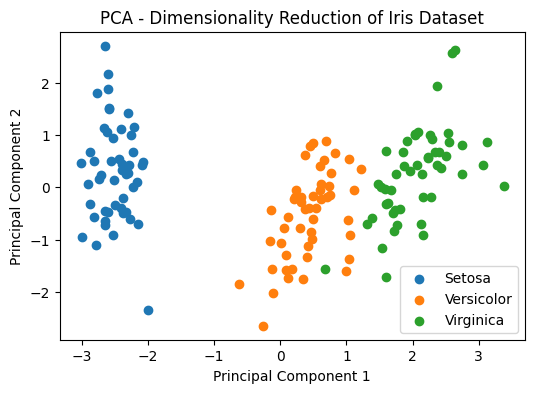

In [3]:
df = pd.read_excel('Iris.xlsx')


print("Dataset Preview:")
print(df.head())


label_encoder = LabelEncoder()
df['Species'] = label_encoder.fit_transform(df['Species'])


X = df.drop('Species', axis=1)
y = df['Species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


pca_df = pd.DataFrame(
    data=X_pca,
    columns=['Principal Component 1',
             'Principal Component 2']
)

pca_df['Species'] = y


print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)


plt.figure(figsize=(6,4))

for species in pca_df['Species'].unique():
    subset = pca_df[pca_df['Species'] == species]

    plt.scatter(
        subset['Principal Component 1'],
        subset['Principal Component 2'],
        label=species
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Dimensionality Reduction of Iris Dataset')
plt.legend(['Setosa', 'Versicolor', 'Virginica'])
plt.show()